In [1]:
!pip install opencv-python-headless matplotlib numpy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving hawkes_bay_in (1).jpg to hawkes_bay_in (1).jpg


  PHASE 6.1 : Image Acquisition & Understanding
  Resolution : 534 x 800
  Channels   : 3
  Data Type  : uint8
  Pixel Matrix (top-left 5x5 grayscale):
[[125 149 160 155 134]
 [181 150 130 123 148]
 [155 141 150 132 142]
 [135 133 152 140 139]
 [146 144 145 137 123]]


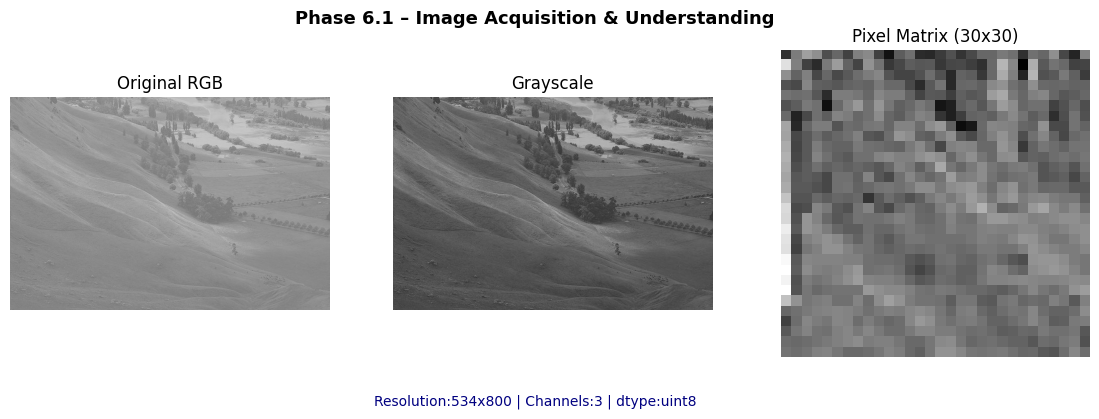


  PHASE 6.2 : Sampling & Quantization
  0.25x (Down)    -> 133 x 200
  0.50x (Down)    -> 267 x 400
  1x (Original)   -> 534 x 800
  1.50x (Up)      -> 801 x 1200
  2x (Up)         -> 1068 x 1600


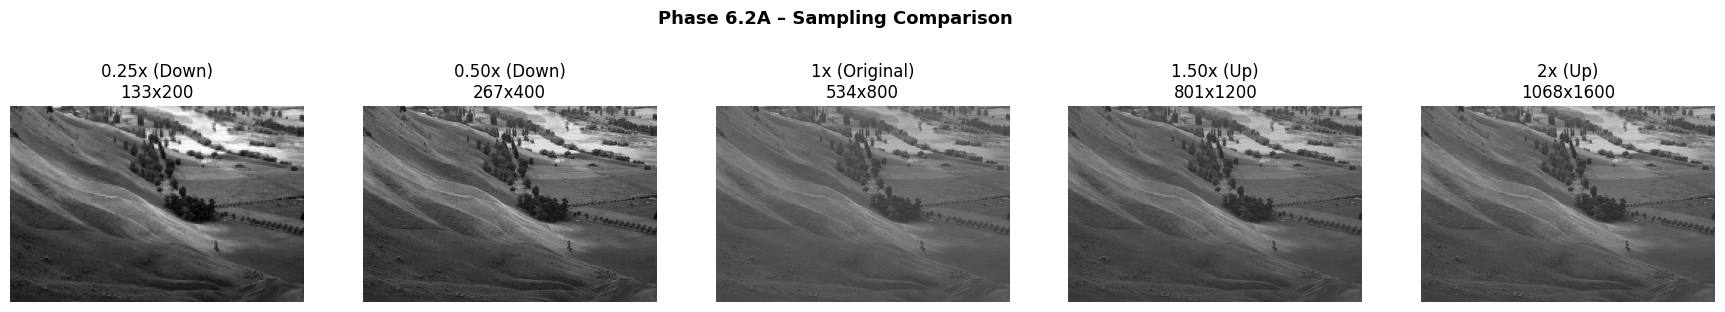

  8-bit -> 256 levels -> Full quality
  4-bit -> 16 levels -> Slight banding
  2-bit -> 4 levels -> Heavy posterisation


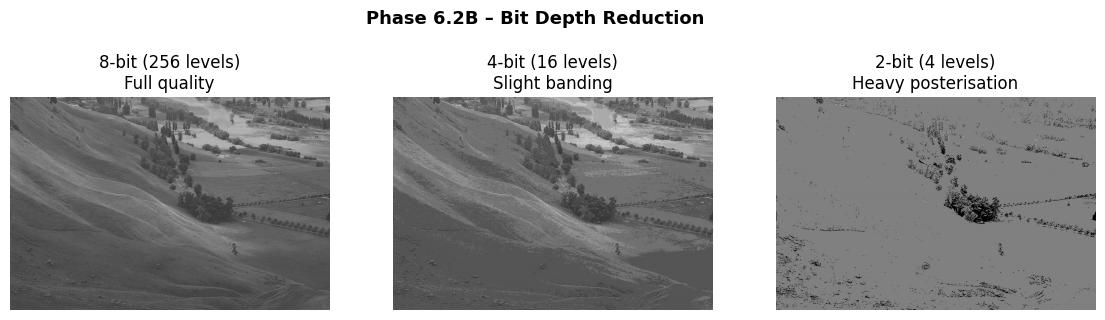


  PHASE 6.3 : Geometric Transformations


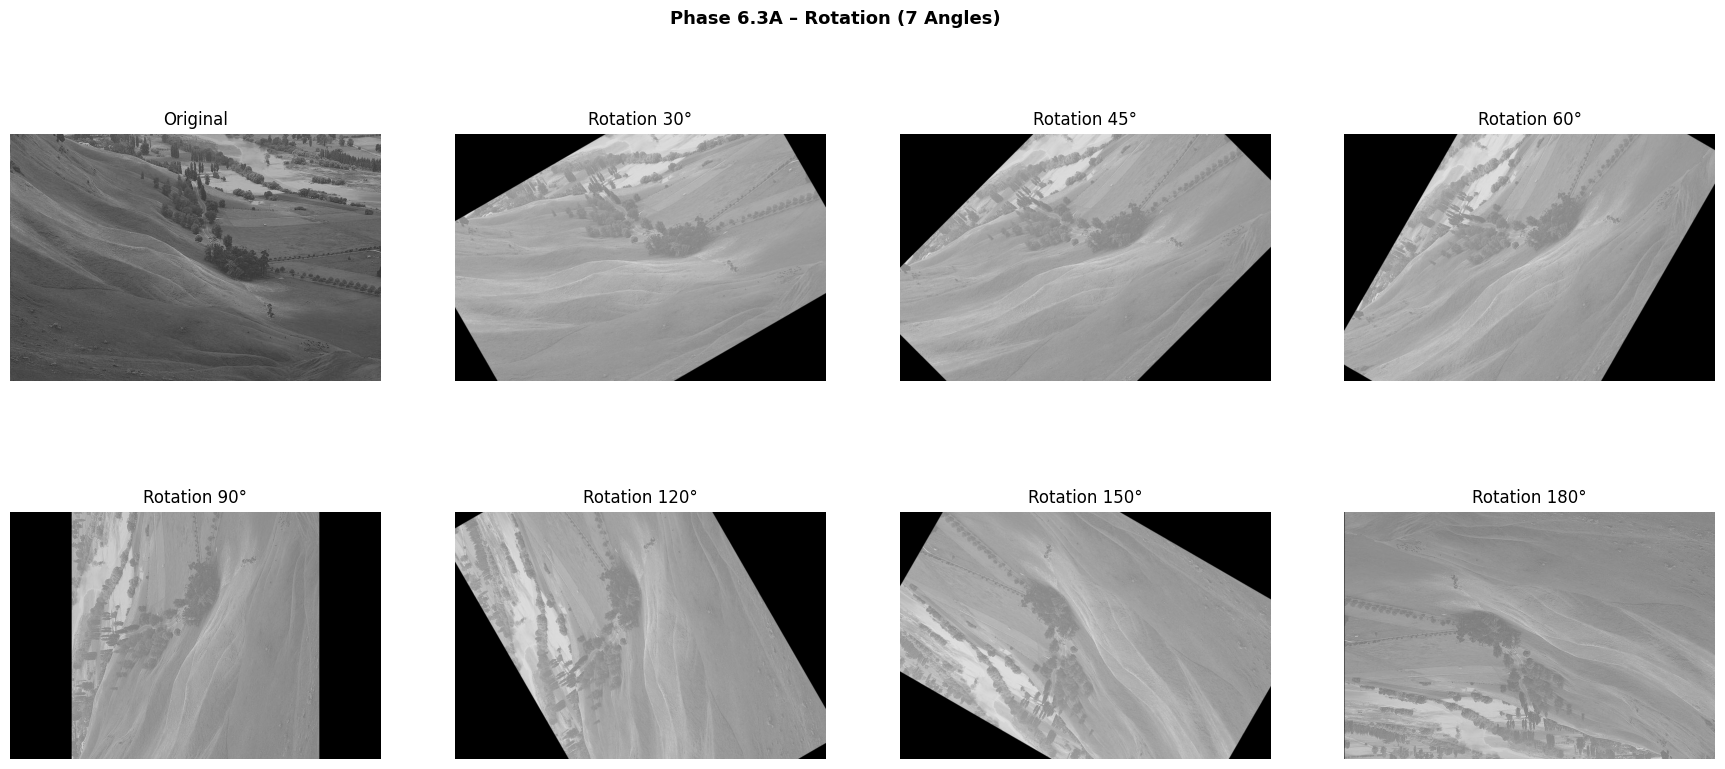

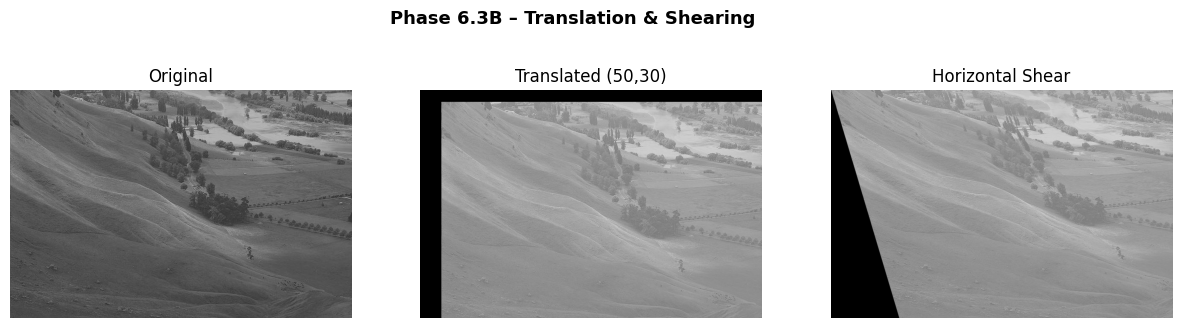

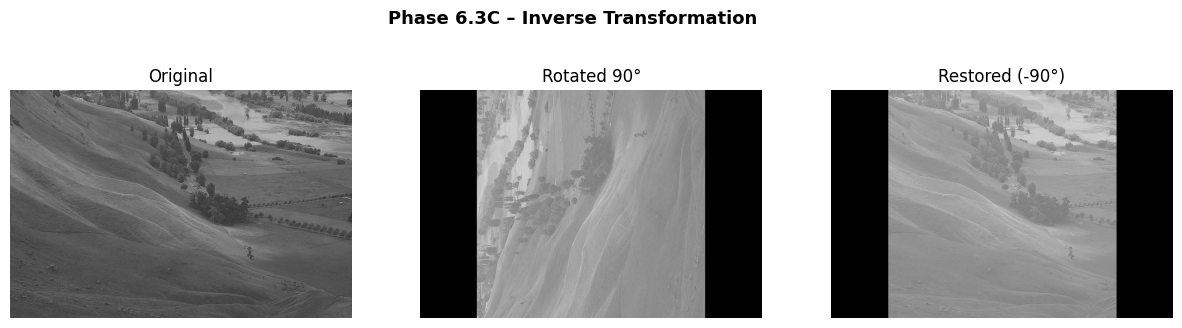

  Translation : tx=50, ty=30 ✓
  Shearing    : Horizontal factor=0.3 ✓
  Inverse     : Rotate 90° → Restore -90° ✓

  PHASE 6.4 : Intensity Transformations


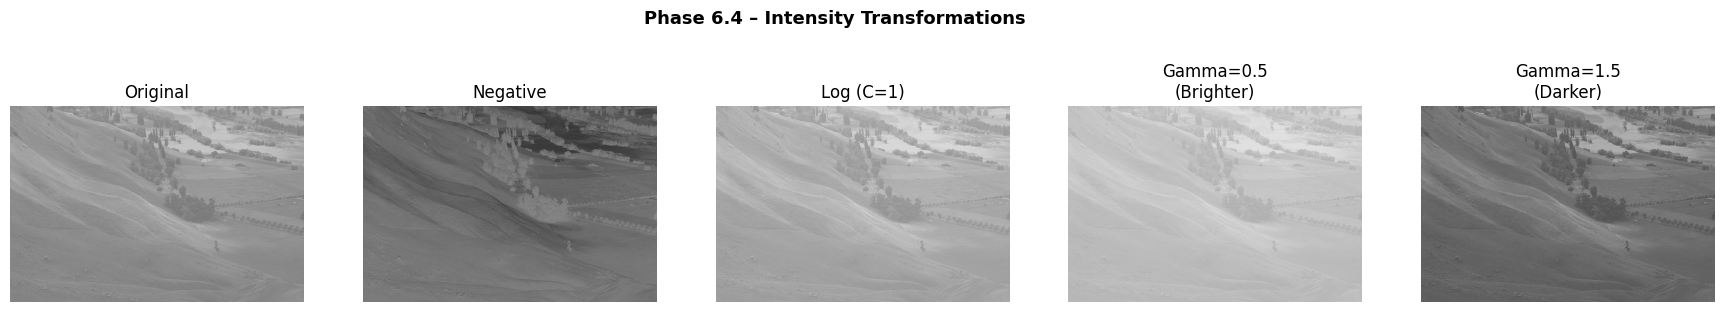

  Gamma=0.5 → BEST for BRIGHTENING ✓
  Log       → BEST for dark detail highlighting ✓

  PHASE 6.5 : Histogram Processing
  Active bins: 143/256 → HIGH contrast


/tmp/ipykernel_2332/3166479449.py:156: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1][col].hist(im.ravel(), 256, (0,255), color='steelblue', edgecolor='none')


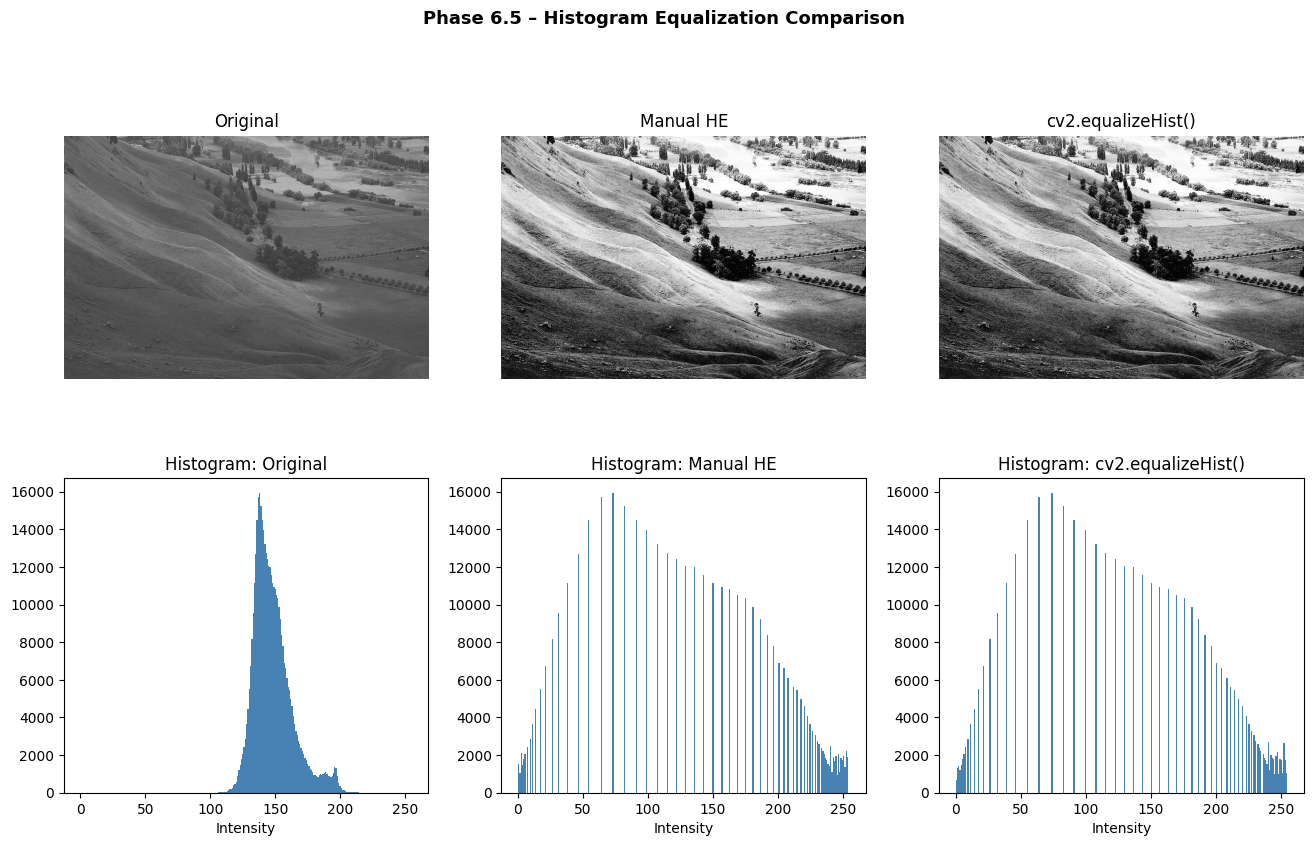

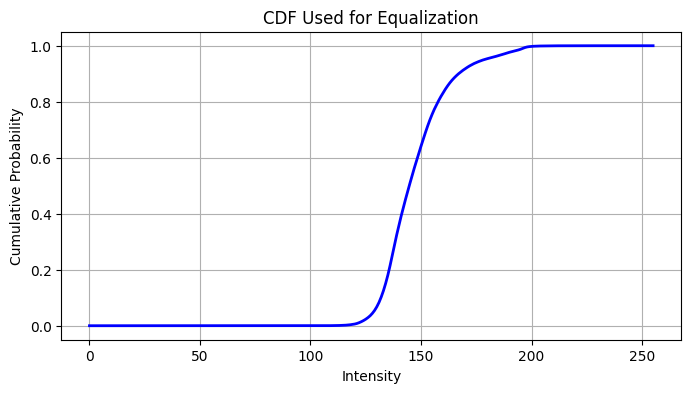

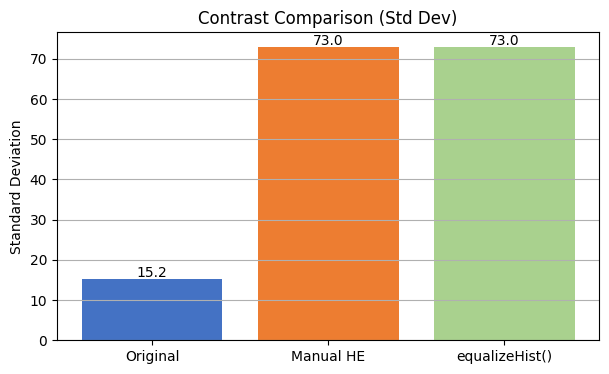

  Std Dev → Original:15.2  ManualHE:73.0  cv2HE:73.0

  PHASE 6.6 : Final Integrated Pipeline


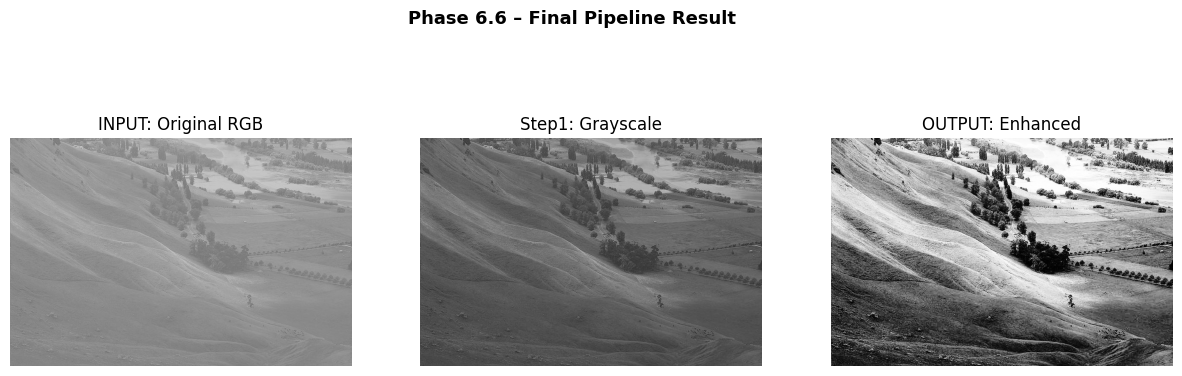

/tmp/ipykernel_2332/3166479449.py:204: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0].hist(img_gray.ravel(),256,(0,255),color='steelblue',edgecolor='none'); axes[0].set_title("Before"); axes[0].set_xlabel("Intensity")
/tmp/ipykernel_2332/3166479449.py:205: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1].hist(enhanced.ravel(),256,(0,255),color='tomato',   edgecolor='none'); axes[1].set_title("After (Enhanced)"); axes[1].set_xlabel("Intensity")


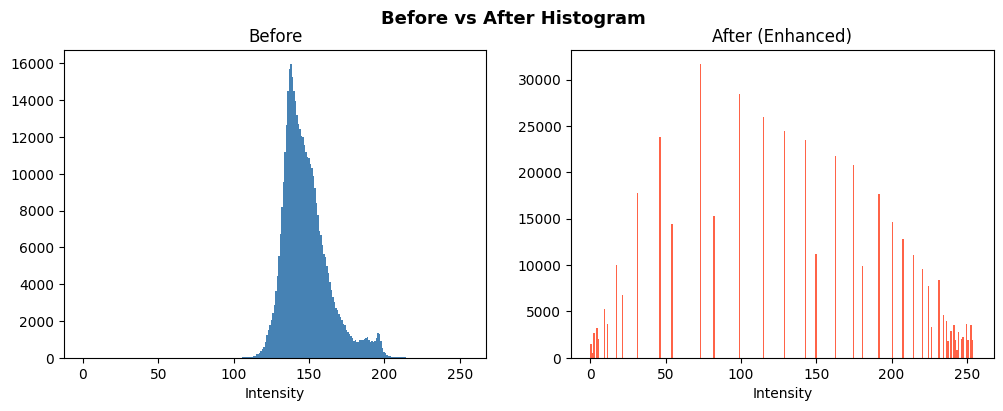

  Pipeline: Grayscale → Log → Gamma(0.5) → HistEQ ✓
  Saved → outputs/235154_enhanced_output.jpg ✓

  Q&A – Section 7.4
Q1: HE spreads intensities across full 0-255 range using CDF → improves contrast.
Q2: Gamma<1 brightens (raises dark pixels). Gamma>1 darkens (compresses brights).
Q3: Fewer bit levels = banding/posterisation = visible quality loss.
Q4: Rotation is reversible (+90°→-90° = original). Quantization is NOT reversible.
Q5: Geometric transforms shift pixel positions. Intensity transforms change pixel values.

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  ALL 6 PHASES COMPLETE ✅
  All figures saved in → outputs/ folder
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [3]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

os.makedirs("outputs", exist_ok=True)
IMAGE_NAME = "hawkes_bay_in (1).jpg"

def save_fig(fig, name):
    fig.savefig(f"outputs/{name}", dpi=120, bbox_inches='tight')
    plt.show(); plt.close(fig)

# ════════════════════════════════════
# PHASE 6.1 – Image Acquisition
# ════════════════════════════════════
img_bgr  = cv2.imread(IMAGE_NAME)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
h, w, c  = img_rgb.shape

print("="*55)
print("  PHASE 6.1 : Image Acquisition & Understanding")
print("="*55)
print(f"  Resolution : {h} x {w}")
print(f"  Channels   : {c}")
print(f"  Data Type  : {img_rgb.dtype}")
print("  Pixel Matrix (top-left 5x5 grayscale):")
print(img_gray[:5, :5])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Phase 6.1 – Image Acquisition & Understanding", fontsize=13, fontweight='bold')
axes[0].imshow(img_rgb);                       axes[0].set_title("Original RGB");       axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray');         axes[1].set_title("Grayscale");           axes[1].axis('off')
axes[2].imshow(img_gray[:30,:30],cmap='gray'); axes[2].set_title("Pixel Matrix (30x30)");axes[2].axis('off')
fig.text(0.5,-0.01,f"Resolution:{h}x{w} | Channels:{c} | dtype:{img_rgb.dtype}",ha='center',fontsize=10,color='navy')
save_fig(fig, "phase61_acquisition.jpg")

# ════════════════════════════════════
# PHASE 6.2 – Sampling & Quantization
# ════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 6.2 : Sampling & Quantization")
print("="*55)

scales  = [0.25, 0.5, 1.0, 1.5, 2.0]
slabels = ['0.25x (Down)', '0.50x (Down)', '1x (Original)', '1.50x (Up)', '2x (Up)']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Phase 6.2A – Sampling Comparison", fontsize=13, fontweight='bold')
for i, s in enumerate(scales):
    nh, nw = int(h*s), int(w*s)
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR
    rs = cv2.resize(img_gray, (nw, nh), interpolation=interp)
    axes[i].imshow(rs, cmap='gray')
    axes[i].set_title(f"{slabels[i]}\n{nh}x{nw}")
    axes[i].axis('off')
    print(f"  {slabels[i]:15} -> {nh} x {nw}")
save_fig(fig, "phase62a_sampling.jpg")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Phase 6.2B – Bit Depth Reduction", fontsize=13, fontweight='bold')
notes = ['Full quality', 'Slight banding', 'Heavy posterisation']
for i, b in enumerate([8, 4, 2]):
    lv = 2**b
    iq = np.uint8(np.round(img_gray/255*(lv-1)) * (255/(lv-1)))
    axes[i].imshow(iq, cmap='gray')
    axes[i].set_title(f"{b}-bit ({lv} levels)\n{notes[i]}")
    axes[i].axis('off')
    print(f"  {b}-bit -> {lv} levels -> {notes[i]}")
save_fig(fig, "phase62b_quantization.jpg")

# ════════════════════════════════════
# PHASE 6.3 – Geometric Transformations
# ════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 6.3 : Geometric Transformations")
print("="*55)
cx, cy = w//2, h//2

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle("Phase 6.3A – Rotation (7 Angles)", fontsize=13, fontweight='bold')
axes = axes.flatten()
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
for i, ang in enumerate([30, 45, 60, 90, 120, 150, 180]):
    M   = cv2.getRotationMatrix2D((cx, cy), ang, 1.0)
    rot = cv2.warpAffine(img_gray, M, (w, h))
    axes[i+1].imshow(rot, cmap='gray')
    axes[i+1].set_title(f"Rotation {ang}°")
    axes[i+1].axis('off')
save_fig(fig, "phase63a_rotation.jpg")

M_t    = np.float32([[1,0,50],[0,1,30]])
img_t  = cv2.warpAffine(img_gray, M_t, (w, h))
pts1   = np.float32([[0,0],[w,0],[0,h]])
pts2   = np.float32([[0,0],[w,0],[int(0.3*h),h]])
M_s    = cv2.getAffineTransform(pts1, pts2)
img_s  = cv2.warpAffine(img_gray, M_s, (w, h))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Phase 6.3B – Translation & Shearing", fontsize=13, fontweight='bold')
for ax,im,t in zip(axes,[img_gray,img_t,img_s],["Original","Translated (50,30)","Horizontal Shear"]):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
save_fig(fig, "phase63b_trans_shear.jpg")

Mf    = cv2.getRotationMatrix2D((cx,cy),  90, 1.0)
Mi    = cv2.getRotationMatrix2D((cx,cy), -90, 1.0)
r90   = cv2.warpAffine(img_gray, Mf, (w, h))
rst   = cv2.warpAffine(r90,      Mi, (w, h))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Phase 6.3C – Inverse Transformation", fontsize=13, fontweight='bold')
for ax,im,t in zip(axes,[img_gray,r90,rst],["Original","Rotated 90°","Restored (-90°)"]):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
save_fig(fig, "phase63c_inverse.jpg")
print("  Translation : tx=50, ty=30 ✓")
print("  Shearing    : Horizontal factor=0.3 ✓")
print("  Inverse     : Rotate 90° → Restore -90° ✓")

# ════════════════════════════════════
# PHASE 6.4 – Intensity Transformations
# ════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 6.4 : Intensity Transformations")
print("="*55)
img_d   = img_gray.astype(np.float64) / 255.0
img_neg = 1.0 - img_d
img_log = np.log1p(img_d); img_log /= img_log.max()
img_g05 = np.power(img_d, 0.5)
img_g15 = np.power(img_d, 1.5)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Phase 6.4 – Intensity Transformations", fontsize=13, fontweight='bold')
for ax,im,t in zip(axes,
                   [img_d, img_neg, img_log, img_g05, img_g15],
                   ["Original","Negative","Log (C=1)","Gamma=0.5\n(Brighter)","Gamma=1.5\n(Darker)"]):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
save_fig(fig, "phase64_intensity.jpg")
print("  Gamma=0.5 → BEST for BRIGHTENING ✓")
print("  Log       → BEST for dark detail highlighting ✓")

# ════════════════════════════════════
# PHASE 6.5 – Histogram Processing
# ════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 6.5 : Histogram Processing")
print("="*55)
counts, _ = np.histogram(img_gray.ravel(), 256, (0, 256))
nonzero   = np.sum(counts > 0)
print(f"  Active bins: {nonzero}/256 → {'LOW contrast' if nonzero<100 else 'HIGH contrast'}")

pdf_v = counts / counts.sum()
cdf_v = np.cumsum(pdf_v)
lut   = np.uint8(255 * cdf_v)
img_eq_m = lut[img_gray]
img_eq_b = cv2.equalizeHist(img_gray)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Phase 6.5 – Histogram Equalization Comparison", fontsize=13, fontweight='bold')
for col, (im, t) in enumerate(zip([img_gray, img_eq_m, img_eq_b],
                                   ["Original","Manual HE","cv2.equalizeHist()"])):
    axes[0][col].imshow(im, cmap='gray'); axes[0][col].set_title(t); axes[0][col].axis('off')
    axes[1][col].hist(im.ravel(), 256, (0,255), color='steelblue', edgecolor='none')
    axes[1][col].set_title(f"Histogram: {t}"); axes[1][col].set_xlabel("Intensity")
save_fig(fig, "phase65_histogram.jpg")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cdf_v, color='blue', linewidth=2)
ax.set_title("CDF Used for Equalization"); ax.set_xlabel("Intensity"); ax.set_ylabel("Cumulative Probability"); ax.grid(True)
save_fig(fig, "phase65_cdf.jpg")

std_o = np.std(img_gray.astype(float))
std_m = np.std(img_eq_m.astype(float))
std_b = np.std(img_eq_b.astype(float))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Original","Manual HE","equalizeHist()"],[std_o,std_m,std_b],color=['#4472C4','#ED7D31','#A9D18E'])
for bar, v in zip(bars,[std_o,std_m,std_b]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{v:.1f}", ha='center')
ax.set_ylabel("Standard Deviation"); ax.set_title("Contrast Comparison (Std Dev)"); ax.grid(axis='y')
save_fig(fig, "phase65_stddev.jpg")
print(f"  Std Dev → Original:{std_o:.1f}  ManualHE:{std_m:.1f}  cv2HE:{std_b:.1f}")

# ════════════════════════════════════
# PHASE 6.6 – Final Integrated Pipeline
# ════════════════════════════════════
print("\n" + "="*55)
print("  PHASE 6.6 : Final Integrated Pipeline")
print("="*55)

def process_image(inp):
    g   = cv2.cvtColor(inp, cv2.COLOR_BGR2GRAY) if len(inp.shape)==3 else inp.copy()
    d   = g.astype(np.float64)/255.0
    lg  = np.log1p(d); lg = (lg/lg.max()*255).astype(np.uint8)
    gm  = np.power(lg.astype(np.float64)/255.0, 0.5)
    gm  = (gm*255).astype(np.uint8)
    cnt,_ = np.histogram(gm.ravel(), 256, (0,256))
    lut2  = np.uint8(255*np.cumsum(cnt/cnt.sum()))
    return lut2[gm]

enhanced = process_image(img_bgr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Phase 6.6 – Final Pipeline Result", fontsize=13, fontweight='bold')
axes[0].imshow(img_rgb);              axes[0].set_title("INPUT: Original RGB");  axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray');axes[1].set_title("Step1: Grayscale");     axes[1].axis('off')
axes[2].imshow(enhanced, cmap='gray');axes[2].set_title("OUTPUT: Enhanced");     axes[2].axis('off')
save_fig(fig, "phase66_pipeline.jpg")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Before vs After Histogram", fontsize=13, fontweight='bold')
axes[0].hist(img_gray.ravel(),256,(0,255),color='steelblue',edgecolor='none'); axes[0].set_title("Before"); axes[0].set_xlabel("Intensity")
axes[1].hist(enhanced.ravel(),256,(0,255),color='tomato',   edgecolor='none'); axes[1].set_title("After (Enhanced)"); axes[1].set_xlabel("Intensity")
save_fig(fig, "phase66_before_after_hist.jpg")

cv2.imwrite("outputs/235154_enhanced_output.jpg", enhanced)
print("  Pipeline: Grayscale → Log → Gamma(0.5) → HistEQ ✓")
print("  Saved → outputs/235154_enhanced_output.jpg ✓")

# ════════════════════════════════════
# Q&A – Section 7.4
# ════════════════════════════════════
print("\n" + "="*55)
print("  Q&A – Section 7.4")
print("="*55)
print("Q1: HE spreads intensities across full 0-255 range using CDF → improves contrast.")
print("Q2: Gamma<1 brightens (raises dark pixels). Gamma>1 darkens (compresses brights).")
print("Q3: Fewer bit levels = banding/posterisation = visible quality loss.")
print("Q4: Rotation is reversible (+90°→-90° = original). Quantization is NOT reversible.")
print("Q5: Geometric transforms shift pixel positions. Intensity transforms change pixel values.")

print("\n" + "★"*55)
print("  ALL 6 PHASES COMPLETE ✅")
print("  All figures saved in → outputs/ folder")
print("★"*55)

In [4]:
import zipfile, os
from google.colab import files

with zipfile.ZipFile("lab06_outputs.zip", "w") as z:
    for f in os.listdir("outputs"):
        z.write(f"outputs/{f}", f)

files.download("lab06_outputs.zip")
print("✅ Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
